# Customer Churn Prediction
**Dataset:** Telco Customer Churn (IBM / Kaggle)  
**Goal:** Build a supervised ML classification model to predict which telecom customers are likely to churn  
**Author:** Muhammad Umer  

---

## Project Overview

Customer churn — the rate at which customers stop doing business with a company — 
is one of the most expensive problems in subscription-based industries. In 
telecommunications, acquiring a new customer costs 5 to 25 times more than 
retaining an existing one. Identifying customers who are *about to leave* before 
they actually do gives the business a window to intervene with targeted retention 
offers.

This notebook builds an end-to-end supervised machine learning pipeline to solve 
that problem. The dataset contains information on 7,032 telecom customers including 
their demographics, account details, subscribed services, and whether they churned.

**The workflow follows nine stages:**

1. Exploratory Data Analysis — understand the churn rate, numerical distributions, 
   and which categorical features visually separate churners from non-churners
2. Data Cleaning — fix dtype issues, handle missing values, drop non-predictive columns
3. Feature Engineering — create three new features that capture customer lifecycle 
   stage, billing patterns, and service engagement
4. Preprocessing Pipeline — build a `ColumnTransformer` inside a `Pipeline` to 
   apply scaling and encoding while preventing data leakage during cross-validation
5. Baseline Model Comparison — compare Logistic Regression, Random Forest, and KNN 
   using 5-fold stratified cross-validation scored on ROC-AUC
6. Hyperparameter Tuning — tune Logistic Regression and Random Forest using 
   `GridSearchCV` and select the stronger tuned model
7. Final Model Evaluation — evaluate the tuned model on the held-out test set 
   using ROC-AUC, accuracy, precision, recall, and confusion matrix
8. Feature Importance and Threshold Analysis — extract model coefficients to 
   identify churn drivers and optimise the decision threshold for business use
9. Business Recommendations — translate findings into prioritised, evidenced 
   actions for a customer retention team

**Tools:** Python 3.13 · pandas · matplotlib · seaborn · scikit-learn 1.8.0

## Step 0 — Setup and Data Loading

Before any analysis begins, we load all libraries the project will use and take a first look at the raw data to understand its structure, column types, and the target variable distribution.

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os               # File path management — used to create the Figures folder
import warnings
warnings.filterwarnings('ignore')   # Suppress convergence and deprecation warnings
                                    # for cleaner notebook output

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np      
import pandas as pd     

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt     
import matplotlib.ticker as mticker # Fine-grained axis formatting (%, comma separators)
import seaborn as sns               

# ── Scikit-learn: Data splitting & validation ─────────────────────────────────
from sklearn.model_selection import (
    train_test_split,   # Splits data into train and test sets — done once, at the start
    StratifiedKFold,    # K-fold cross-validation that preserves class proportions
                        # Essential here because churn (~26%) is an imbalanced class —
                        # regular KFold can produce folds with very few churners
    cross_val_score,    # Runs CV on a model and returns per-fold scores
    GridSearchCV        # Exhaustive hyperparameter search with built-in cross-validation
)

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# StandardScaler  — normalises numerical features to mean=0, std=1
#                   Required for Logistic Regression and KNN which are distance-sensitive
# OneHotEncoder   — converts categorical columns (e.g. Contract type) into binary columns
#                   sklearn's version handles unknown categories gracefully

from sklearn.impute import SimpleImputer
# Fills missing values — we will discover one column with blanks in Step 2

from sklearn.compose import ColumnTransformer
# Applies different preprocessing steps to different column subsets simultaneously
# e.g. scale numerical columns AND one-hot encode categorical columns in one step

from sklearn.pipeline import Pipeline
# Chains preprocessing + model into a single object
# This is the production-ready approach — it prevents data leakage because
# the scaler never sees test data during cross-validation or GridSearch

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
# Interpretable linear classifier — strong baseline for binary classification
# Outputs probabilities, which is essential for ROC-AUC scoring

from sklearn.ensemble import RandomForestClassifier
# Tree-based ensemble — handles non-linear relationships and interactions between features
# Also provides feature importances directly (Step 8)

from sklearn.neighbors import KNeighborsClassifier
# Distance-based classifier — included as a third comparison point
# Sensitive to feature scale, which is why scaling inside the pipeline matters

# ── Scikit-learn: Evaluation metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,         # % of correct predictions — useful context but misleading alone
    roc_auc_score,          # Primary metric: measures how well the model separates the two
                            # classes regardless of threshold. 0.5 = random, 1.0 = perfect
    precision_score,        # Of all predicted churners, how many actually churned?
    recall_score,           # Of all actual churners, how many did we catch?
                            # Recall is usually more important in churn — missing a churner
                            # costs more than a false alarm
    confusion_matrix,       # 2x2 table of TP, FP, FN, TN — visualised as heatmap
    classification_report   # Full per-class breakdown of precision, recall, F1
)

# ── Global plot settings ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'Arial'   # Avoids font-related rendering issues on Windows
plt.rcParams['figure.dpi'] = 120

# ── Output folder ─────────────────────────────────────────────────────────────
FIGURES_DIR = 'Figures'
os.makedirs(FIGURES_DIR, exist_ok=True)  # Creates folder if it doesn't exist yet

print('All libraries imported successfully.')
print(f'scikit-learn version: {__import__("sklearn").__version__}')

All libraries imported successfully.
scikit-learn version: 1.8.0


---
### Load and Inspect the Raw Data

We load the CSV and immediately check three things:
- **Shape** — how many rows and columns do we have?
- **Data types** — are all columns stored as the correct type? (Spoiler: one is not.)
- **Target variable** — what is the churn rate and is the dataset imbalanced?

These three checks determine everything that comes next in Steps 1 and 2.

In [2]:
# ── Load the CSV ──────────────────────────────────────────────────────────────
CSV_PATH = os.path.join('Data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(CSV_PATH)

# ── Shape and column names ────────────────────────────────────────────────────
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Columns:')
print(df.columns.tolist())

Shape: 7,043 rows × 21 columns

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# ── Data types ────────────────────────────────────────────────────────────────
# We check dtypes before anything else — dtype errors silently break downstream
# operations (e.g. a numeric column stored as object cannot be scaled)
print('--- Data Types ---')
print(df.dtypes)

--- Data Types ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No null values detected.')

--- Missing Values ---
No null values detected.


In [5]:
# ── Target variable distribution ──────────────────────────────────────────────
# Class imbalance affects which CV strategy and metrics we use throughout the project
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('--- Target Variable: Churn ---')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(1)}))

--- Target Variable: Churn ---
       Count  Percentage
Churn                   
No      5174        73.5
Yes     1869        26.5


In [6]:
# ── First look at the data ────────────────────────────────────────────────────
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 0 Findings

The dataset contains 7,043 customers across 21 columns. 

Three immediate observations from the first inspection:

- **TotalCharges is stored as string** despite being a numeric billing column. This is because a small number of rows contain blank strings instead of a numeric value. This will be converted to float and the blank rows handled in Step 2.
- **SeniorCitizen is stored as int64** (0/1) rather than Yes/No like the other binary columns. We will treat it as categorical during preprocessing to keep it consistent with the rest of the binary features.
- **The dataset is moderately imbalanced** — 73.5% of customers did not churn versus 26.5% who did. This rules out accuracy as a reliable evaluation metric and confirms that StratifiedKFold and ROC-AUC are the correct choices for model comparison in Steps 5 and 6.

## Step 1 — Exploratory Data Analysis

Before building any model, we need to understand the data visually. EDA serves a specific purpose here, we are trying to answer one question: **which features separate churners from non-churners?**

Any feature that shows a meaningful difference in distribution between the two churn classes is a candidate for a strong predictor. Any feature that looks identical across both classes is likely to contribute little to the model.

We structure EDA into three parts:
1. **Target distribution** — visualise the class imbalance we confirmed in Step 0
2. **Numerical features** — distributions, means by churn class, and correlations
3. **Categorical features** — churn rate broken down by the most business-relevant variables

No data is modified in this step. Cleaning happens in Step 2.

### 1.1 Target Distribution

We already know the split is 73.5% / 26.5% from Step 0. Here we visualise it to make the imbalance concrete before any modelling decisions are made.

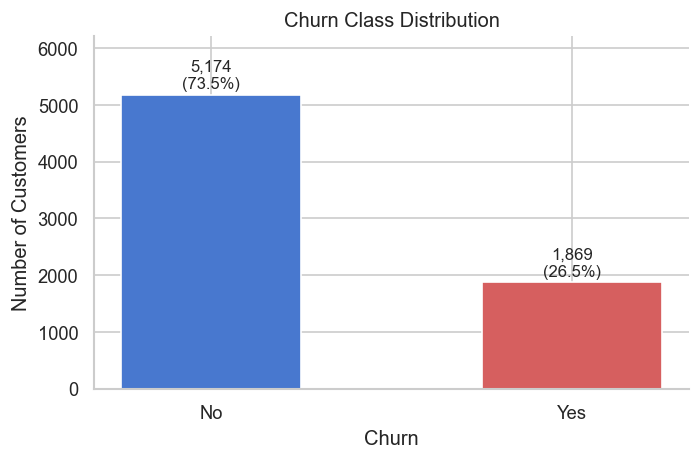

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = df['Churn'].value_counts()
colors = ['#4878CF', '#D65F5F']

bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, width=0.5)

# Annotate each bar with count and percentage
for bar, (label, count) in zip(bars, churn_counts.items()):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Churn Class Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.2)
sns.despine()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'churn_distribution.png'), bbox_inches='tight')
plt.show()

### 1.2 Numerical Features

The dataset has three meaningful numerical columns: `tenure`, `MonthlyCharges`, and `TotalCharges`.

For each we look at:
- The distribution split by churn class — does the shape differ between churners and non-churners?
- The mean value by churn class — is there a directional signal?

`TotalCharges` is still a string at this point so we create a temporary numeric version for visualisation only. The permanent conversion happens in Step 2.

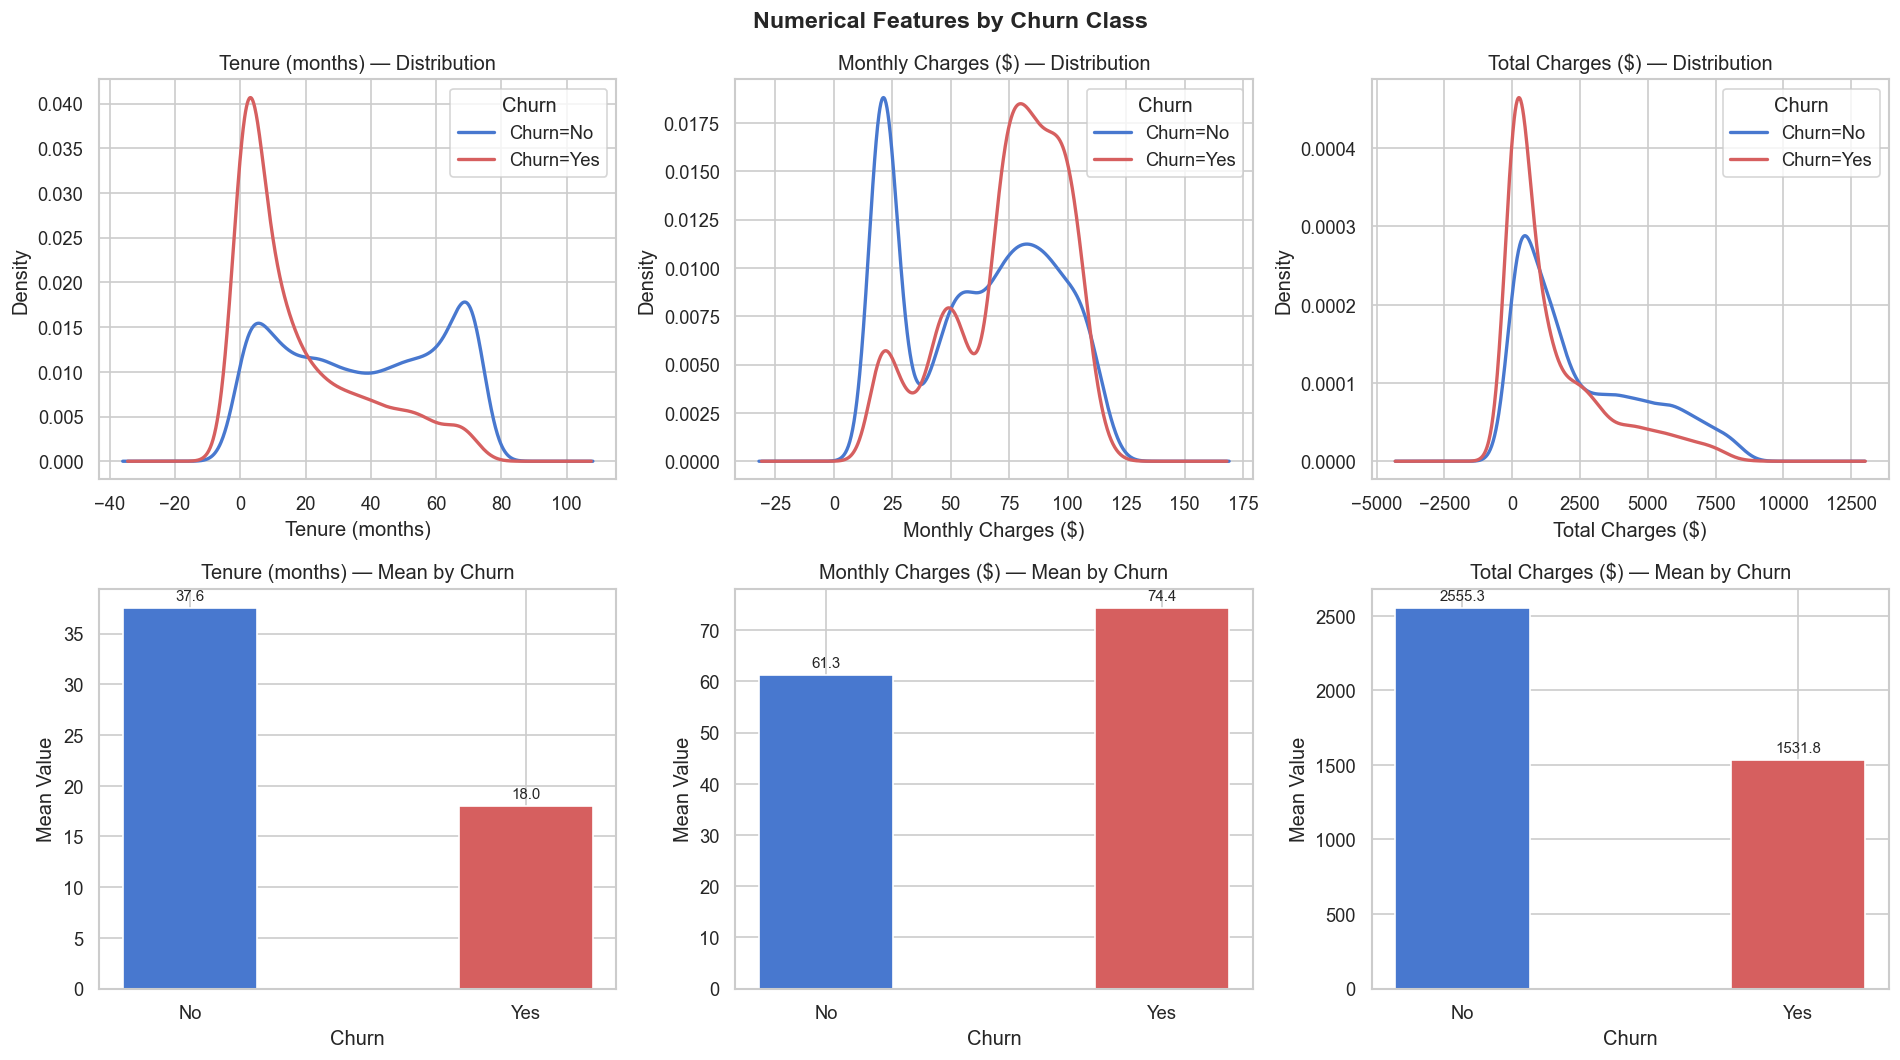

In [8]:
# Temporary numeric conversion for EDA only — permanent fix is in Step 2
df['TotalCharges_temp'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_temp']
num_labels = ['Tenure (months)', 'Monthly Charges ($)', 'Total Charges ($)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Features by Churn Class', fontsize=14, fontweight='bold')

palette = {'No': '#4878CF', 'Yes': '#D65F5F'}

for i, (col, label) in enumerate(zip(num_cols, num_labels)):
    # Row 1 — KDE distributions
    ax_kde = axes[0, i]
    for churn_val, color in palette.items():
        subset = df[df['Churn'] == churn_val][col].dropna()
        subset.plot.kde(ax=ax_kde, label=f'Churn={churn_val}', color=color, linewidth=2)
    ax_kde.set_title(f'{label} — Distribution')
    ax_kde.set_xlabel(label)
    ax_kde.legend(title='Churn')

    # Row 2 — Mean by churn class
    ax_bar = axes[1, i]
    means = df.groupby('Churn')[col].mean()
    bar_colors = [palette[k] for k in means.index]
    ax_bar.bar(means.index, means.values, color=bar_colors, width=0.4)
    for j, (idx, val) in enumerate(means.items()):
        ax_bar.text(j, val + means.max() * 0.02, f'{val:.1f}',
                    ha='center', fontsize=9)
    ax_bar.set_title(f'{label} — Mean by Churn')
    ax_bar.set_xlabel('Churn')
    ax_bar.set_ylabel('Mean Value')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'numerical_features_by_churn.png'), bbox_inches='tight')
plt.show()

# Drop the temporary column
df.drop(columns=['TotalCharges_temp'], inplace=True)

### 1.3 Correlation Matrix — Numerical Features

A correlation matrix tells us two things: how strongly each numerical feature relates to the others, and whether any features are so highly correlated that one becomes redundant. We include a temporary numeric version of `TotalCharges` and a binary encoding of `Churn` (1 = churned) to see directional relationships with the target.

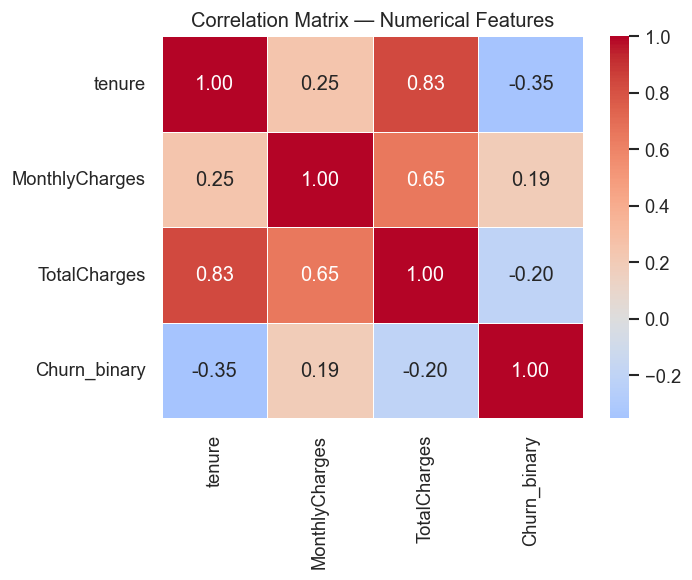

In [9]:
df_corr = df[['tenure', 'MonthlyCharges']].copy()
df_corr['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_corr['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_matrix.png'), bbox_inches='tight')
plt.show()

### 1.4 Categorical Features — Churn Rate by Key Variables

For categorical features we calculate the churn rate within each category — the percentage of customers in that group who churned. This is more informative than raw counts because it controls for category size.

We focus on the four most business-relevant variables:
- **Contract type** — month-to-month vs one/two-year contracts
- **Internet service** — fibre, DSL, or none
- **Payment method** — how the customer pays
- **Tenure group** — we bin tenure into bands here for visualisation purposes; the engineered feature is created properly in Step 3

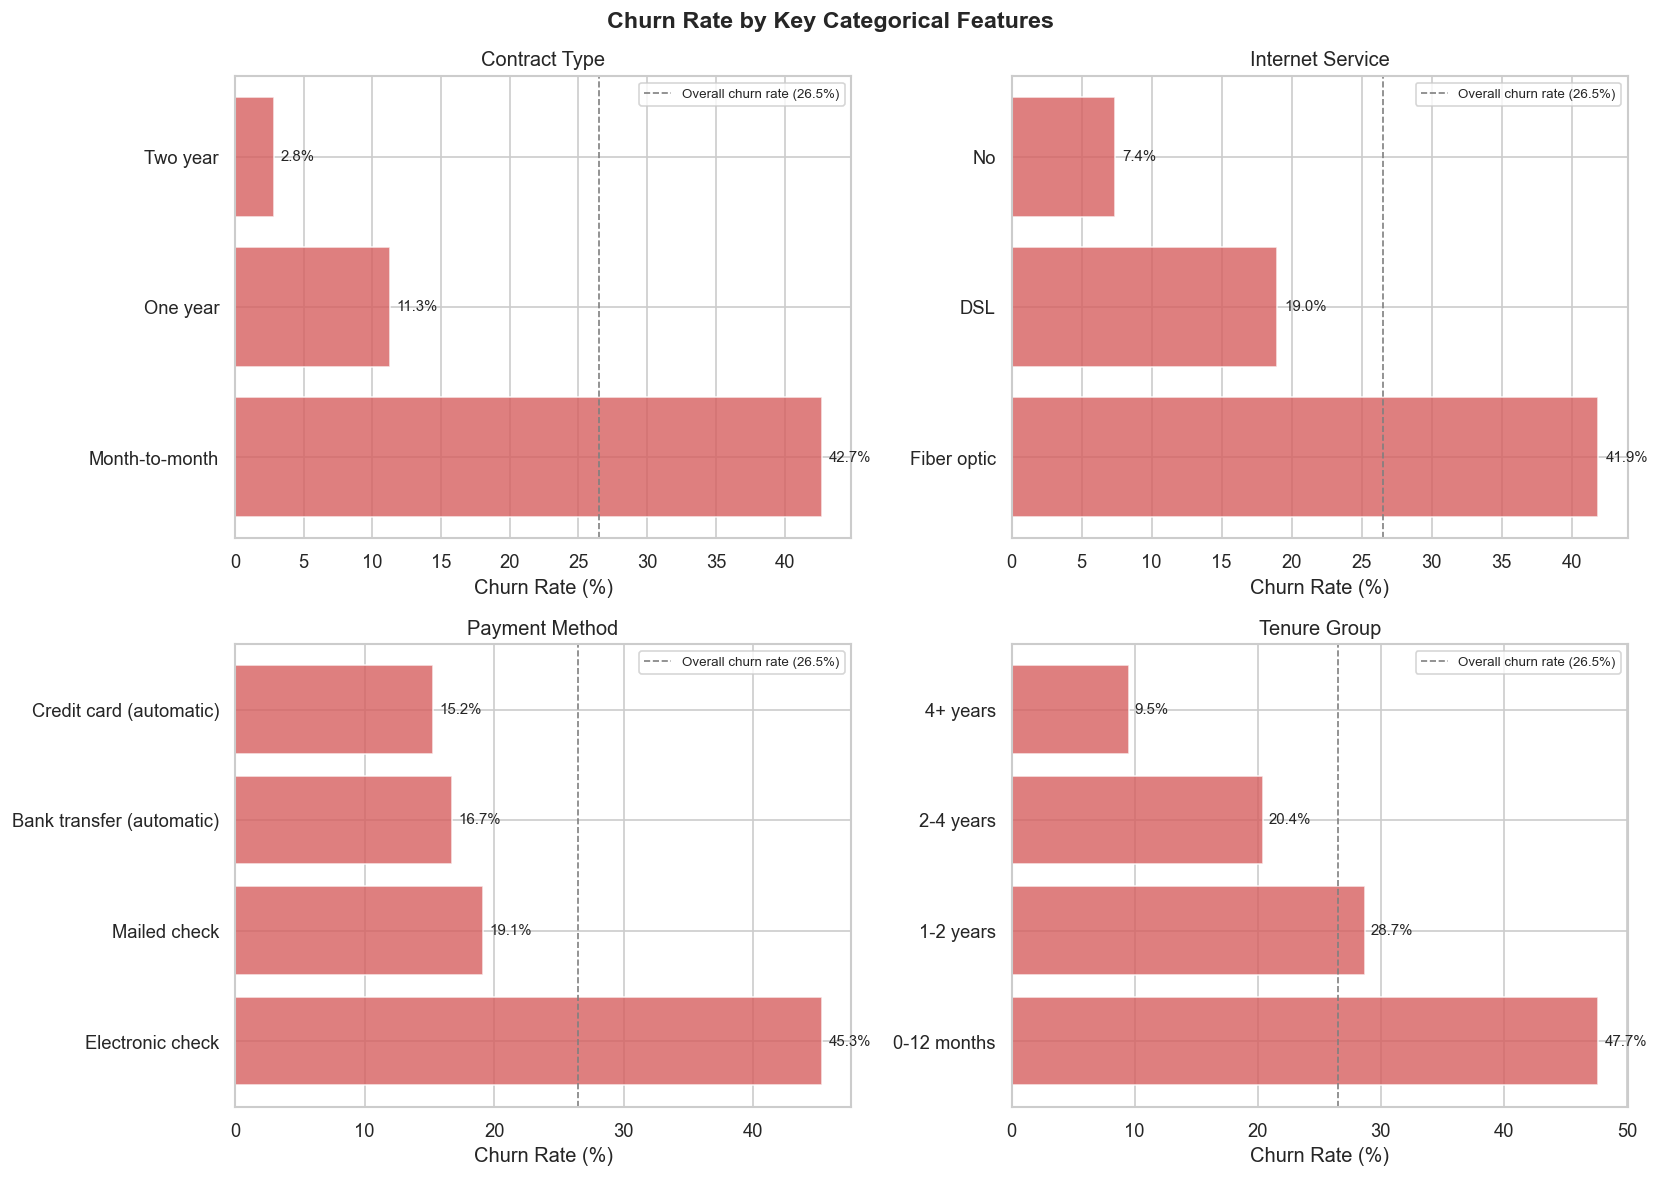

In [10]:
# Tenure bins for visualisation only
df['tenure_group_temp'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '1-2 years', '2-4 years', '4+ years']
)

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'tenure_group_temp']
cat_labels = ['Contract Type', 'Internet Service', 'Payment Method', 'Tenure Group']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes.flatten(), cat_cols, cat_labels):
    churn_rate = (df.groupby(col)['Churn']
                    .apply(lambda x: (x == 'Yes').sum() / len(x) * 100)
                    .reset_index())
    churn_rate.columns = [col, 'Churn Rate (%)']
    churn_rate = churn_rate.sort_values('Churn Rate (%)', ascending=False)

    bars = ax.barh(churn_rate[col].astype(str), churn_rate['Churn Rate (%)'],
                   color='#D65F5F', alpha=0.8)

    for bar, val in zip(bars, churn_rate['Churn Rate (%)']):
        ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=9)

    ax.axvline(26.5, color='gray', linestyle='--', linewidth=1,
               label='Overall churn rate (26.5%)')
    ax.set_title(label)
    ax.set_xlabel('Churn Rate (%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'categorical_churn_rates.png'), bbox_inches='tight')
plt.show()

df.drop(columns=['tenure_group_temp'], inplace=True)

### Step 1: EDA Findings

**Tenure is the strongest numerical predictor of churn.** Churners leave early — the distribution spikes near 0 months and drops sharply, while loyal customers spread across the full 0-72 month range. Mean tenure for churners is 18 months versus 37.6 months for non-churners.

**Churners pay higher monthly charges but lower total charges.** Mean monthly charges for churners are $74.4 versus $61.3 for non-churners — but total charges are lower ($1,531 vs $2,555). This is not a contradiction: churners leave before accumulating high totals. The underlying driver is likely plan type, which the categorical analysis confirms.

**TotalCharges and tenure are highly collinear (r = 0.83).** TotalCharges is largely a function of how long a customer has been with the company. As a raw feature it adds limited information beyond tenure. The engineered `monthly_to_total_ratio` feature in Step 3 extracts more meaningful signal from this relationship.

**The negative x-axis values in the tenure and TotalCharges KDE plots are visual artifacts** — KDE smoothing extends slightly beyond the minimum data values. No actual negative values exist in the data.

**Contract type shows the strongest categorical separation.** Month-to-month customers churn at 42.7% — more than 15 times the rate of two-year contract holders (2.8%). This is the single clearest business signal in the dataset. Customers who have not committed to a long-term contract have no switching cost.

**Fibre optic customers churn at 41.9% despite paying for the premium service.** This is counterintuitive — higher-tier internet customers are leaving at nearly the same rate as month-to-month contract holders. Combined with the MonthlyCharges finding above, this suggests a price-to-value perception problem specifically with the fibre product.

**Electronic check users churn at 45.3% — the highest of any payment category.** Automatic payment methods (credit card, bank transfer) cluster well below the overall average. Manual payment behaviour may be a proxy for lower engagement and weaker commitment to the service.

**The tenure group chart confirms the non-linear relationship we saw in the KDE plot.** Churn drops sharply from 47.7% in the first year to 9.5% after four years. The biggest intervention window is the 0-12 month cohort — nearly half of new customers who will eventually leave do so within their first year.

## Step 2 — Data Cleaning

EDA surfaced three issues that need to be resolved before any modelling can happen:

1. **`TotalCharges` is stored as string** — blank strings exist in place of numeric values for a small number of rows. We convert the column to float and handle the blanks.
2. **`customerID` has no predictive value** — it is a unique identifier per row. Including it would add noise and no signal.
3. **`SeniorCitizen` is stored as 0/1 integers** — every other binary column in the dataset uses Yes/No strings. We convert it for consistency so the preprocessing pipeline in Step 4 treats it the same way as the other binary features.

### 2.1 Fix TotalCharges

`pd.to_numeric()` with `errors='coerce'` converts the column to float and turns any non-numeric string (the blanks) into `NaN`. We then inspect exactly how many rows are affected and who those customers are before deciding what to do with them.

In [12]:
# All affected rows have tenure = 0 — these are brand new customers with no charges yet
# Dropping them is the correct decision: 11 rows out of 7,043 is 0.16% of the data
# Imputing would introduce a false billing value for customers who haven't been billed
# Convert TotalCharges to numeric — blank strings become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f'NaN values after conversion: {df["TotalCharges"].isna().sum()}')
print(f'dtype: {df["TotalCharges"].dtype}')
print()

# Inspect affected rows before dropping
blank_rows = df[df['TotalCharges'].isna()]
print(blank_rows[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
print()

# Drop — all affected rows have tenure = 0, imputing would be misleading
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f'Rows after dropping: {len(df):,}')
print(f'Rows removed: {7043 - len(df)}')

NaN values after conversion: 11
dtype: float64

      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No

Rows after dropping: 7,032
Rows removed: 11


### 2.3 Drop customerID

`customerID` is a unique string identifier assigned per customer. It carries no information about behaviour, demographics, or service usage — including it in a model would be equivalent to giving each row a random label. It is dropped permanently here.

In [13]:
df = df.drop(columns=['customerID'])

print(f'Columns after dropping customerID: {df.shape[1]}')
print(df.columns.tolist())

Columns after dropping customerID: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


### 2.4 Standardise SeniorCitizen Encoding

`SeniorCitizen` is currently stored as 0 and 1. Every other binary categorical column in the dataset — `Partner`, `Dependents`, `PhoneService`, `Churn` etc. — uses Yes/No strings. We convert `SeniorCitizen` to match so the preprocessing pipeline in Step 4 can apply identical treatment to all binary columns without special-casing this one.

In [14]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print('SeniorCitizen value counts after conversion:')
print(df['SeniorCitizen'].value_counts())

SeniorCitizen value counts after conversion:
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64


### 2.5 Final Cleaned Dataset — Verification

A final check to confirm the dataset is clean and ready for feature engineering. 
We verify shape, dtypes, and that no nulls remain anywhere.

In [15]:
print(f'Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('--- dtypes ---')
print(df.dtypes)
print()
print('--- Remaining nulls ---')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else 'No null values remaining.')

Final shape: 7,032 rows x 20 columns

--- dtypes ---
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

--- Remaining nulls ---
No null values remaining.


### Step 2 Findings

The dataset required three cleaning steps before modelling:

**TotalCharges converted and 11 rows dropped.** The column was stored as a string due to 11 blank entries. Converting to float revealed these were all customers with `tenure = 0` — brand new customers who had not yet been billed. Imputing a value would have introduced artificial billing data for customers with no real charges. Dropping them removes 0.16% of the data with no meaningful information loss.

**customerID dropped.** A unique identifier per row with no predictive signal. Removing it reduces the column count from 21 to 20.

**SeniorCitizen converted from 0/1 to No/Yes.** Standardised to match the encoding of all other binary columns so the preprocessing pipeline in Step 4 treats it identically.

**Final clean dataset: 7,032 rows × 20 columns. No null values remaining.**

## Step 3 — Feature Engineering

Raw features tell the model what a customer looks like today. Engineered features tell it something more nuanced — where the customer is in their lifecycle, how much value they are extracting per month, and how embedded they are in the service.

We create three new features, each directly motivated by findings from EDA:

1. **`tenure_group`** — bins tenure into four lifecycle bands. The KDE plot in Step 1 showed churn is not linearly related to tenure — it spikes in the first year and drops sharply after year two. Binning captures this non-linear pattern explicitly rather than leaving it to the model to approximate.

2. **`monthly_to_total_ratio`** — MonthlyCharges divided by TotalCharges. The correlation matrix showed tenure and TotalCharges are 83% correlated, meaning TotalCharges adds little information beyond what tenure already encodes. This ratio captures something neither raw column does: how early in their lifetime a customer currently is. A high ratio means high monthly spend relative to lifetime spend — i.e. a newer, potentially at-risk customer.

3. **`num_services`** — a count of how many add-on services each customer has subscribed to. Customers with more services have higher switching costs — cancelling means losing multiple products simultaneously. This is a proxy for engagement and lock-in that no single service column captures alone.

### 3.1 Tenure Group

We bin tenure into four bands that reflect natural customer lifecycle stages. 

The cut points are chosen based on the churn rate chart from Step 1:
- 0–12 months: highest risk cohort (47.7% churn rate)
- 1–2 years: elevated risk, still above average (28.7%)
- 2–4 years: approaching average (20.4%)
- 4+ years: loyal customers, well below average (9.5%)

In [16]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '1-2 years', '2-4 years', '4+ years'],
    include_lowest=True
)

print('Tenure group distribution:')
print(df['tenure_group'].value_counts().sort_index())
print()
print('Churn rate by tenure group (validation):')
print(df.groupby('tenure_group')['Churn']
        .apply(lambda x: f"{(x == 'Yes').mean() * 100:.1f}%"))

Tenure group distribution:
tenure_group
0-12 months    2175
1-2 years      1024
2-4 years      1594
4+ years       2239
Name: count, dtype: int64

Churn rate by tenure group (validation):
tenure_group
0-12 months    47.7%
1-2 years      28.7%
2-4 years      20.4%
4+ years        9.5%
Name: Churn, dtype: str


### 3.2 Monthly to Total Charges Ratio

This ratio answers the question: what fraction of a customer's total lifetime spend with the company is their current monthly bill?

- A **high ratio** (close to 1) means the customer has only been paying for a short time — their total charges have barely accumulated. These are newer customers who are statistically more likely to churn.
- A **low ratio** (close to 0) means the customer has been paying for a long time and their total charges have grown well beyond their monthly bill. These are the loyal, long-tenure customers.

We add a small constant (0.01) to the denominator to avoid division by zero for any edge cases where TotalCharges might be zero.

In [17]:
df['monthly_to_total_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 0.01)

print('monthly_to_total_ratio — summary statistics:')
print(df['monthly_to_total_ratio'].describe().round(4))
print()
print('Mean ratio by churn class:')
print(df.groupby('Churn')['monthly_to_total_ratio'].mean().round(4))

monthly_to_total_ratio — summary statistics:
count    7032.0000
mean        0.1576
std         0.2814
min         0.0126
25%         0.0181
50%         0.0347
75%         0.1137
max         0.9999
Name: monthly_to_total_ratio, dtype: float64

Mean ratio by churn class:
Churn
No     0.1036
Yes    0.3066
Name: monthly_to_total_ratio, dtype: float64


### 3.3 Number of Services

We count how many of the six available add-on services each customer has subscribed to: OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies.

Each of these columns contains three possible values: 'Yes', 'No', or 'No internet service'. Only 'Yes' counts as an active subscription.
The resulting integer (0–6) is a single number that summarises how deeply embedded a customer is in the product ecosystem.

In [18]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Count columns where the value is explicitly 'Yes'
df['num_services'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

print('num_services distribution:')
print(df['num_services'].value_counts().sort_index())
print()
print('Mean num_services by churn class:')
print(df.groupby('Churn')['num_services'].mean().round(2))

num_services distribution:
num_services
0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: count, dtype: int64

Mean num_services by churn class:
Churn
No     2.14
Yes    1.77
Name: num_services, dtype: float64


### 3.4 Verify Engineered Features
A final check to confirm all three features were created correctly and the 
dataset shape is as expected.

In [19]:
new_features = ['tenure_group', 'monthly_to_total_ratio', 'num_services']

print(f'Dataset shape after feature engineering: {df.shape}')
print()
print('New feature dtypes:')
print(df[new_features].dtypes)
print()
print('Sample of engineered features (first 5 rows):')
df[['tenure', 'MonthlyCharges', 'TotalCharges'] + new_features].head()

Dataset shape after feature engineering: (7032, 23)

New feature dtypes:
tenure_group              category
monthly_to_total_ratio     float64
num_services                 int64
dtype: object

Sample of engineered features (first 5 rows):


,tenure,MonthlyCharges,TotalCharges,tenure_group,monthly_to_total_ratio,num_services
0,1,29.85,29.85,0-12 months,0.999665,1
1,34,56.95,1889.50,2-4 years,0.030140,2
2,2,53.85,108.15,0-12 months,0.497874,2
3,45,42.30,1840.75,2-4 years,0.022980,3
4,2,70.70,151.65,0-12 months,0.466174,0


## Step 4 — Preprocessing Pipeline

Before any model sees the data, the features need to be in the right format. 
This step builds a preprocessing pipeline that handles three transformations:

- **Scaling** — numerical features are standardised to mean=0, std=1. Logistic Regression and KNN are sensitive to feature scale — a tenure value of 72 and a MonthlyCharges value of 100 are on completely different scales and would distort distance-based calculations without normalisation.
- **Encoding** — categorical features are converted into binary columns using OneHotEncoder. A model cannot work with strings like "Month-to-month" directly.
- **Imputation** — a SimpleImputer is included as a safeguard. There are no missing values in the current dataset, but if the pipeline is applied to new incoming customer data in production, unseen nulls would otherwise break it.

**Why a Pipeline and not manual preprocessing?**

The critical reason is **data leakage**. If we scaled the entire dataset before splitting into train and test, the scaler would have "seen" the test data during fitting — the test set's mean and standard deviation would influence the transformation. A Pipeline ensures the scaler and encoder are fitted only on the training data and then applied to the test set, exactly as they would be in production.

### 4.1 Define Feature Columns

We separate the 22 feature columns into three groups based on how they need to be preprocessed: numerical (scale), categorical (encode), and the target. `tenure_group` is categorical despite being derived from a numeric column — it is stored as a pandas Categorical and will be one-hot encoded.

In [20]:
# ── Define target variable ────────────────────────────────────────────────────
# Convert Churn from Yes/No string to binary integer (1 = churned, 0 = stayed)
# sklearn models require a numeric target for binary classification
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# ── Separate features and target ──────────────────────────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']

# ── Identify column types for the ColumnTransformer ──────────────────────────
# Numerical columns — will be imputed then scaled
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
            'monthly_to_total_ratio', 'num_services']

# Categorical columns — will be imputed then one-hot encoded
# tenure_group is cast to string so OneHotEncoder handles it consistently
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

# Convert tenure_group to string — it is stored as pandas Categorical dtype
# which can cause issues inside sklearn's ColumnTransformer
X['tenure_group'] = X['tenure_group'].astype(str)

print(f'Total features: {X.shape[1]}')
print(f'Numerical columns ({len(num_cols)}): {num_cols}')
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Target distribution — 0 (No churn): {(y==0).sum():,} | 1 (Churn): {(y==1).sum():,}')

Total features: 22
Numerical columns (5): ['tenure', 'MonthlyCharges', 'TotalCharges', 'monthly_to_total_ratio', 'num_services']
Categorical columns (17): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Target distribution — 0 (No churn): 5,163 | 1 (Churn): 1,869


### 4.2 Train-Test Split

We split the data into 80% training and 20% test sets before building the pipeline. The test set is set aside now and will not be touched until the final evaluation in Step 7.

`stratify=y` ensures both splits contain the same ~26.5% churn proportion. 
Without stratification, random sampling could produce a test set with a very different class balance, making evaluation results unreliable.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Preserve the 26.5% / 73.5% churn ratio in both splits
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')
print()
# Verify stratification worked — both splits should show ~26.5% churn
print('Churn rate in training set: '
      f'{y_train.mean()*100:.1f}%')
print('Churn rate in test set:     '
      f'{y_test.mean()*100:.1f}%')

Training set:  5,625 rows
Test set:      1,407 rows

Churn rate in training set: 26.6%
Churn rate in test set:     26.6%


### 4.3 Build the Preprocessing Pipeline

We use `ColumnTransformer` to apply different transformations to different column subsets simultaneously, then wrap it inside a `Pipeline` alongside the model placeholder.

The `ColumnTransformer` has two branches:
- **numerical pipeline** — impute missing values with the column mean, then scale to mean=0 std=1
- **categorical pipeline** — impute missing values with the most frequent category, then one-hot encode

`handle_unknown='ignore'` in the encoder means that if the pipeline encounters a category in new data that it never saw during training, it outputs all zeros for that column rather than throwing an error. This is important for robustness in production.

In [22]:
# ── Numerical preprocessing branch ───────────────────────────────────────────
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),     # Fill any nulls with column mean
    ('scaler', StandardScaler())                     # Standardise to mean=0, std=1
])

# ── Categorical preprocessing branch ─────────────────────────────────────────
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill nulls with mode
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',    # Unseen categories in new data → all zeros
        sparse_output=False         # Return a dense array — easier to inspect
    ))
])

# ── Combine both branches into a single ColumnTransformer ────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, num_cols),
    ('cat', categorical_pipeline, cat_cols)
])

print('Preprocessor built successfully.')
print()
print(preprocessor)

Preprocessor built successfully.

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges',
                                  'monthly_to_total_ratio', 'num_services']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                         

### 4.4 Verify the Preprocessor on Training Data

Before attaching any model, we fit and transform the training data through the preprocessor alone to confirm the output shape is correct. The number of output columns will be larger than the input because OneHotEncoder expands each categorical column into multiple binary columns.

In [23]:
# Fit only on training data — test data is never seen during fitting
X_train_processed = preprocessor.fit_transform(X_train)

# Get feature names after one-hot encoding for later use in feature importance
feature_names = (
    num_cols +
    list(preprocessor.named_transformers_['cat']
                      .named_steps['encoder']
                      .get_feature_names_out(cat_cols))
)

print(f'Input feature count:  {X_train.shape[1]}')
print(f'Output feature count: {X_train_processed.shape[1]}')
print(f'Training rows:        {X_train_processed.shape[0]:,}')
print()
print(f'First 5 feature names after encoding:')
print(feature_names[:5])
print(f'Last 5 feature names after encoding:')
print(feature_names[-5:])

Input feature count:  22
Output feature count: 52
Training rows:        5,625

First 5 feature names after encoding:
['tenure', 'MonthlyCharges', 'TotalCharges', 'monthly_to_total_ratio', 'num_services']
Last 5 feature names after encoding:
['PaymentMethod_Mailed check', 'tenure_group_0-12 months', 'tenure_group_1-2 years', 'tenure_group_2-4 years', 'tenure_group_4+ years']


### Step 4 Findings

**Train-test split successful.** 5,625 training rows and 1,407 test rows — an 80/20 split. Stratification worked correctly: both sets show exactly 26.6% churn, matching the overall dataset rate. The test set is now locked away and will not be touched until Step 7.

**OneHotEncoding expanded 22 input features to 52 output features.** The 17 categorical columns were expanded into 47 binary columns — each unique category becomes its own column. The 5 numerical columns pass through unchanged. This expansion is expected and handled automatically by the ColumnTransformer.

**No data leakage.** The preprocessor was fitted exclusively on the training set (`fit_transform` on `X_train`). When applied to `X_test` in Step 7, it will use the scaling parameters and encoder vocabulary learned from training data only — exactly as it would behave on unseen data in production.

## Step 5 — Baseline Model Comparison

Before tuning any hyperparameters, we run three classification models in their default configuration to establish a baseline. This screening step answers a practical question: which model family is worth investing time in tuning?

The three candidates are:
- **Logistic Regression** — a linear classifier that outputs probabilities directly. Interpretable, fast, and a strong baseline for binary classification problems.

- **Random Forest** — an ensemble of decision trees that handles non-linear relationships and feature interactions well. Also provides feature importances.

- **K-Nearest Neighbours (KNN)** — a distance-based classifier that predicts based on the majority class of the k closest training points.

**Why ROC-AUC and not accuracy?**

Accuracy would tell us very little here. A model that predicts nobody churns would score 73.4% accuracy by doing nothing useful. ROC-AUC measures how well the model separates the two classes across all possible decision thresholds — a score of 0.5 means random guessing, 1.0 means perfect separation. It is the correct metric for imbalanced binary classification.

**Why StratifiedKFold and not KFold?**

With a 26.6% churn rate, regular KFold splits could produce folds with very different class proportions by chance. StratifiedKFold guarantees that each fold contains approximately the same churn rate as the full training set, making the cross-validation scores stable and comparable across models.

Each model is wrapped in a full Pipeline with the preprocessor from Step 4 — this means preprocessing is re-fitted on each training fold during cross-validation, with no leakage into the validation fold.

### 5.1 Define Models and Cross-Validation Strategy

We define three full pipelines — one per model — each containing the preprocessor from Step 4 followed by the classifier. Running cross-validation on the full pipeline rather than preprocessed data is the correct approach: it simulates exactly what will happen when the model sees new data.

In [24]:
# ── Cross-validation strategy ─────────────────────────────────────────────────
# 5 folds, stratified to preserve churn rate in each fold, fixed seed for reproducibility
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Define one full pipeline per model ───────────────────────────────────────
# Each pipeline: preprocessor (Step 4) + classifier
# The preprocessor is re-fitted on each training fold — no leakage
pipelines = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
        # max_iter=1000 — default 100 is sometimes insufficient for convergence
        # on datasets with many features after one-hot encoding
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'KNN': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
        # Default k=5 — distance-sensitive, scaling inside pipeline handles this
    ])
}

print('Pipelines defined:')
for name in pipelines:
    print(f'  - {name}')

Pipelines defined:
  - Logistic Regression
  - Random Forest
  - KNN


### 5.2 Run Cross-Validation

We run 5-fold stratified cross-validation for each pipeline and collect the ROC-AUC score for every fold. This gives us 5 scores per model — enough to compare both the median performance and the variance (consistency) across folds.

A model with a high median but wide spread is less reliable than one with a slightly lower median but tight, consistent scores.

In [25]:
cv_results = {}

for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline,
        X_train, y_train,
        cv=cv,
        scoring='roc_auc',   # Primary metric — measures class separation ability
        n_jobs=-1            # Use all available CPU cores to speed up computation
    )
    cv_results[name] = scores
    print(f'{name}:')
    print(f'  Fold scores: {[round(s, 4) for s in scores]}')
    print(f'  Mean ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Logistic Regression:
  Fold scores: [np.float64(0.8468), np.float64(0.8502), np.float64(0.8484), np.float64(0.8501), np.float64(0.8571)]
  Mean ROC-AUC: 0.8505 (+/- 0.0035)

Random Forest:
  Fold scores: [np.float64(0.8332), np.float64(0.8187), np.float64(0.8235), np.float64(0.8359), np.float64(0.8362)]
  Mean ROC-AUC: 0.8295 (+/- 0.0071)

KNN:
  Fold scores: [np.float64(0.7921), np.float64(0.7592), np.float64(0.7864), np.float64(0.7954), np.float64(0.7851)]
  Mean ROC-AUC: 0.7836 (+/- 0.0128)



### 5.3 Visualise Cross-Validation Results

A box plot shows both the median ROC-AUC and the spread across folds for each model side by side. We add a reference line at 0.5 (random classifier) to give the scores context, and annotate each box with the mean score.

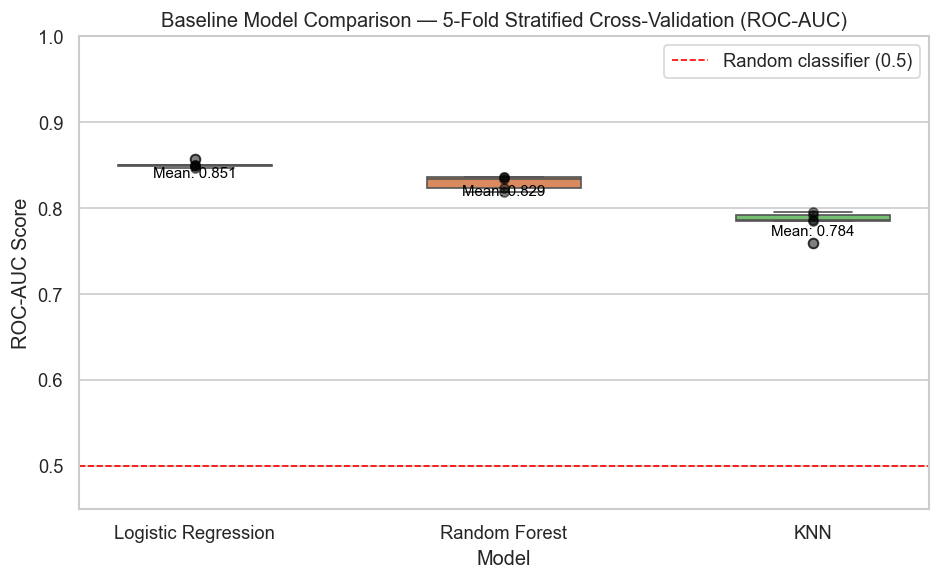

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

# Build a DataFrame for seaborn
cv_df = pd.DataFrame(cv_results)

# Box plot — each box shows median, IQR, and range across 5 folds
sns.boxplot(data=cv_df, palette='muted', width=0.5, ax=ax)

# Overlay individual fold scores as points for full transparency
for i, col in enumerate(cv_df.columns):
    ax.scatter([i] * len(cv_df[col]), cv_df[col],
               color='black', alpha=0.5, zorder=5, s=30)

# Reference line — a score of 0.5 is equivalent to random guessing
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random classifier (0.5)')

# Annotate each box with the mean score
for i, col in enumerate(cv_df.columns):
    ax.text(i, cv_df[col].mean() - 0.015,
            f'Mean: {cv_df[col].mean():.3f}',
            ha='center', fontsize=9, color='black')

ax.set_title('Baseline Model Comparison — 5-Fold Stratified Cross-Validation (ROC-AUC)')
ax.set_ylabel('ROC-AUC Score')
ax.set_xlabel('Model')
ax.set_ylim(0.45, 1.0)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'baseline_model_comparison.png'), bbox_inches='tight')
plt.show()

### Step 5 Findings

**Logistic Regression is the clear winner** with a mean ROC-AUC of 0.851 and the tightest variance across folds (±0.003). It outperforms both Random Forest (0.830) and KNN (0.784) in their default configurations.

**Logistic Regression is also the most consistent model.** Its fold scores range from 0.847 to 0.857 — a spread of just 0.010. Random Forest shows more variance (±0.007) and KNN the most (±0.013), making both less reliable across unseen data splits.

**KNN performs the worst despite proper scaling.** A mean ROC-AUC of 0.784 suggests the decision boundary in this dataset is not well-captured by distance to nearest neighbours — the feature relationships are more linear than spatial.

**Logistic Regression will be carried forward into Step 6** for hyperparameter tuning. The gap between it and Random Forest (0.851 vs 0.830) is meaningful enough to make the choice straightforward.

## Step 6 — Hyperparameter Tuning

Logistic Regression won the baseline comparison with a mean ROC-AUC of 0.851 in its default configuration. The question now is: how much can we improve on that by tuning its key hyperparameters?

We use `GridSearchCV` to systematically search over a grid of hyperparameter combinations. For each combination, it runs 5-fold stratified cross-validation on the training set and scores it using ROC-AUC. The combination with the highest mean ROC-AUC across folds is selected as the best model.

**The two hyperparameters we tune:**

- **`C`** — the inverse of regularisation strength. A small C applies strong regularisation, shrinking coefficients toward zero and reducing overfitting at the cost of some bias. A large C applies weak regularisation, allowing the model to fit the training data more closely. We search across a wide logarithmic range to find the right balance.

- **`solver`** — the algorithm used to optimise the logistic regression objective function. Different solvers have different strengths depending on dataset size and feature count. We test three that are appropriate for this dataset size and binary classification task.

The full pipeline (preprocessor + classifier) is passed to GridSearchCV — not just the classifier. This ensures preprocessing is re-fitted correctly on each training fold during the search, with zero data leakage.

### 6.1 Define the Hyperparameter Grid

We search over 3 solvers × 10 values of C = 30 combinations. Each combination is evaluated with 5-fold cross-validation, meaning GridSearchCV fits and evaluates 150 models in total. This is computationally manageable while being thorough enough to find a well-optimised model.

In [27]:
# ── Build the pipeline to be tuned ───────────────────────────────────────────
# A fresh pipeline instance — preprocessor + Logistic Regression
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# ── Define the hyperparameter grid ───────────────────────────────────────────
# Parameter names follow the format: stepname__parametername
# 'classifier__C' refers to the C parameter of the LogisticRegression step
param_grid = {
    'classifier__C': np.logspace(-3, 0, 10),  # 10 values from 0.001 to 1.0 on log scale
    'classifier__solver': ['newton-cg', 'saga', 'lbfgs']  # Three appropriate solvers
}

print('Hyperparameter grid:')
print(f"  C values: {[round(c, 5) for c in param_grid['classifier__C']]}")
print(f"  Solvers:  {param_grid['classifier__solver']}")
print(f"  Total combinations: {len(param_grid['classifier__C']) * len(param_grid['classifier__solver'])}")
print(f"  Total fits (combinations x folds): "
      f"{len(param_grid['classifier__C']) * len(param_grid['classifier__solver']) * 5}")

Hyperparameter grid:
  C values: [np.float64(0.001), np.float64(0.00215), np.float64(0.00464), np.float64(0.01), np.float64(0.02154), np.float64(0.04642), np.float64(0.1), np.float64(0.21544), np.float64(0.46416), np.float64(1.0)]
  Solvers:  ['newton-cg', 'saga', 'lbfgs']
  Total combinations: 30
  Total fits (combinations x folds): 150


### 6.2 Run GridSearchCV

We pass the full pipeline to GridSearchCV with the same StratifiedKFold strategy used in Step 5 for consistency. `refit=True` means that once the best hyperparameters are found, GridSearchCV automatically re-fits the best pipeline on the entire training set — ready for final evaluation.

In [28]:
grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    cv=cv,                  # Same StratifiedKFold from Step 5
    scoring='roc_auc',      # Consistent with the metric used in baseline comparison
    refit=True,             # Re-fit best model on full training set after search
    n_jobs=-1,              # Parallelise across all CPU cores
    verbose=1               # Print progress so we can see it running
)

grid_search.fit(X_train, y_train)

print()
print(f'Best parameters:  {grid_search.best_params_}')
print(f'Best ROC-AUC (CV): {grid_search.best_score_:.4f}')
print(f'Improvement over baseline: '
      f'+{(grid_search.best_score_ - 0.8505)*100:.2f} percentage points')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters:  {'classifier__C': np.float64(0.046415888336127774), 'classifier__solver': 'newton-cg'}
Best ROC-AUC (CV): 0.8508
Improvement over baseline: +0.03 percentage points


### 6.3 Inspect the Full Results

Looking at the top combinations gives us confidence that the best result is not a lucky outlier — if the top 5 combinations all score similarly, the model is stable around that performance level. We also check whether C or solver made more of a difference.

In [29]:
# Convert GridSearch results to a DataFrame for easy inspection
results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_classifier__C', 'param_classifier__solver',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

results_df.columns = ['C', 'Solver', 'Mean ROC-AUC', 'Std', 'Rank']
results_df['Mean ROC-AUC'] = results_df['Mean ROC-AUC'].round(4)
results_df['Std'] = results_df['Std'].round(4)
results_df['C'] = results_df['C'].round(5)

print('Top 10 hyperparameter combinations:')
print(results_df.head(10).to_string(index=False))

Top 10 hyperparameter combinations:
      C    Solver  Mean ROC-AUC    Std  Rank
0.04642 newton-cg        0.8508 0.0031     1
0.04642     lbfgs        0.8508 0.0031     2
0.04642      saga        0.8507 0.0031     3
0.10000 newton-cg        0.8507 0.0033     4
0.10000      saga        0.8507 0.0033     5
0.10000     lbfgs        0.8507 0.0032     6
0.21544     lbfgs        0.8507 0.0034     7
0.02154     lbfgs        0.8507 0.0030     8
0.02154 newton-cg        0.8506 0.0030     9
0.21544      saga        0.8506 0.0034    10


### 6.4 Visualise the Effect of C on ROC-AUC

Plotting mean ROC-AUC against C values for each solver shows us the regularisation landscape — where performance peaks, and whether the optimal C is at the boundary of our search range (which would suggest we need to search further).

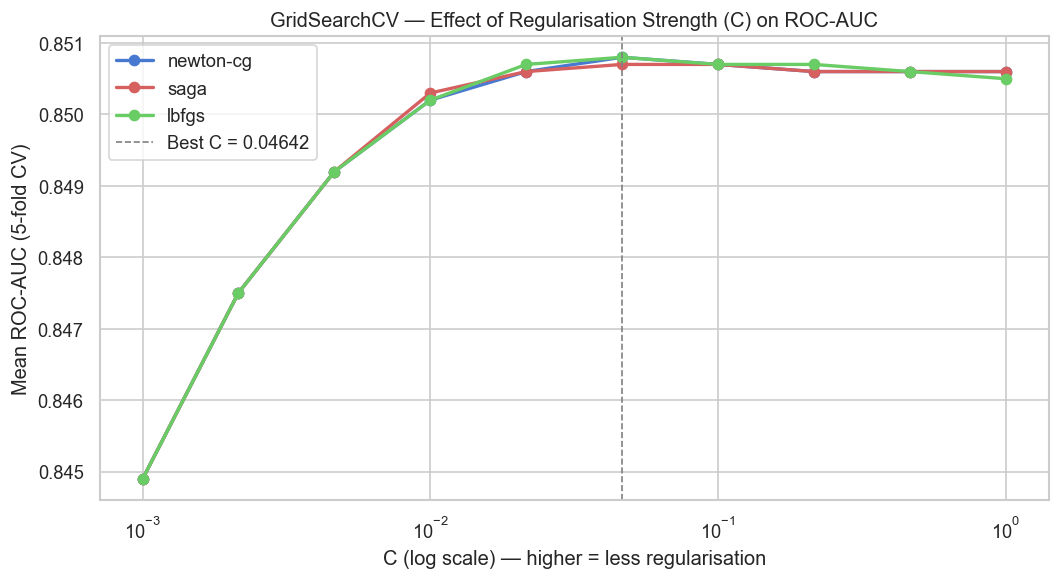

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = {'newton-cg': '#4878CF', 'saga': '#D65F5F', 'lbfgs': '#6ACC65'}

for solver in param_grid['classifier__solver']:
    subset = results_df[results_df['Solver'] == solver].sort_values('C')
    ax.plot(subset['C'], subset['Mean ROC-AUC'],
            marker='o', label=solver, color=colors[solver], linewidth=2)

# Mark the best combination
best_C = round(grid_search.best_params_['classifier__C'], 5)
best_solver = grid_search.best_params_['classifier__solver']
ax.axvline(best_C, color='gray', linestyle='--', linewidth=1,
           label=f'Best C = {best_C}')

ax.set_xscale('log')   # Log scale matches how we defined the search range
ax.set_title('GridSearchCV — Effect of Regularisation Strength (C) on ROC-AUC')
ax.set_xlabel('C (log scale) — higher = less regularisation')
ax.set_ylabel('Mean ROC-AUC (5-fold CV)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'gridsearch_results.png'), bbox_inches='tight')
plt.show()

### Step 6 Findings

**Best parameters: C = 0.046, solver = newton-cg, ROC-AUC = 0.8508.**

**Tuning produced no meaningful improvement over the baseline** — the gain of +0.03 percentage points over the default configuration (0.8505) is negligible. The top 10 combinations in the grid all score within 0.001 of each other, and all three solvers perform virtually identically at the optimal C value.

**The chart tells the real story.** Performance rises as C increases from 0.001 to ~0.046 — meaning the default configuration was over-regularised. Beyond C = 0.046 the curve flattens completely. The optimal C sits comfortably in the middle of the search range, confirming we did not need to extend the grid.

**The implication is that Logistic Regression has reached its ceiling on this dataset.** The decision boundary in the Telco churn problem is likely not perfectly linear — contract type, fibre optic service, and payment method interact in ways a linear model cannot fully capture.

### 6.5 Tune Random Forest

Logistic Regression gained only +0.03 percentage points from tuning, suggesting it has reached its performance ceiling on this dataset. The linear decision boundary LR assumes may not fully capture the interactions between contract type, internet service, and payment method that EDA revealed.

Random Forest scored 0.830 at baseline — 2.1 points behind LR. However, tree-based ensembles often benefit more from tuning than linear models because they have more structural hyperparameters to optimise. We tune four key hyperparameters:

- **`n_estimators`** — number of trees in the forest. More trees generally improve stability up to a point of diminishing returns.
- **`max_depth`** — maximum depth of each tree. Unconstrained trees overfit; limiting depth acts as regularisation.
- **`min_samples_leaf`** — minimum number of samples required at a leaf node. Higher values prevent the model from learning noise in individual records.
- **`max_features`** — number of features considered at each split. Controls diversity between trees — lower values make trees more independent of each other.

In [31]:
# ── Build Random Forest pipeline ──────────────────────────────────────────────
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# ── Hyperparameter grid ───────────────────────────────────────────────────────
# Kept deliberately focused — wide grids on RF are computationally expensive
rf_param_grid = {
    'classifier__n_estimators': [100, 200],          # Number of trees
    'classifier__max_depth': [None, 10, 20],         # None = fully grown trees
    'classifier__min_samples_leaf': [1, 2, 4],       # Minimum samples per leaf
    'classifier__max_features': ['sqrt', 'log2']     # Features considered per split
}

total_combinations = 2 * 3 * 3 * 2
print(f'Total combinations: {total_combinations}')
print(f'Total fits (combinations x folds): {total_combinations * 5}')

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print()
print(f'Best parameters:   {rf_grid_search.best_params_}')
print(f'Best ROC-AUC (CV): {rf_grid_search.best_score_:.4f}')
print(f'Improvement over RF baseline: '
      f'+{(rf_grid_search.best_score_ - 0.8295)*100:.2f} percentage points')

Total combinations: 36
Total fits (combinations x folds): 180
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters:   {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
Best ROC-AUC (CV): 0.8481
Improvement over RF baseline: +1.86 percentage points


### 6.6 Compare Tuned Models

We compare the tuned versions of both models side by side against their baseline scores. This determines which model carries forward into the final evaluation in Step 7.

In [32]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Baseline ROC-AUC': [0.8505, 0.8295],
    'Tuned ROC-AUC': [
        round(grid_search.best_score_, 4),
        round(rf_grid_search.best_score_, 4)
    ]
})

comparison['Improvement'] = (
    comparison['Tuned ROC-AUC'] - comparison['Baseline ROC-AUC']
).round(4)

print(comparison.to_string(index=False))

print()
print('Model selected for final evaluation:')
best_model_name = comparison.loc[
    comparison['Tuned ROC-AUC'].idxmax(), 'Model'
]
print(f'  → {best_model_name}')

# Store the winning pipeline for use in Step 7
if best_model_name == 'Logistic Regression':
    best_pipeline = grid_search
else:
    best_pipeline = rf_grid_search

              Model  Baseline ROC-AUC  Tuned ROC-AUC  Improvement
Logistic Regression            0.8505         0.8508       0.0003
      Random Forest            0.8295         0.8481       0.0186

Model selected for final evaluation:
  → Logistic Regression


### Step 6 Findings

**Logistic Regression tuning result:** Best parameters C = 0.046, solver = newton-cg, ROC-AUC = 0.8508. Improvement of +0.03 percentage points over baseline — negligible. The model plateaus beyond C = 0.046, confirming it has reached its performance ceiling on this dataset.

**Random Forest tuning result:** Best parameters — max_depth = 10, max_features = log2, min_samples_leaf = 4, n_estimators = 200. Tuned ROC-AUC = 0.8481, an improvement of +1.86 percentage points over the RF baseline of 0.830. Constraining tree depth to 10 and requiring at least 4 samples per leaf acted as effective regularisation — the default unconstrained trees were overfitting.

**Model selected for Step 7: Logistic Regression.** Despite Random Forest's larger relative improvement from tuning, Logistic Regression remains the stronger model at 0.8508 vs 0.8481. The gap is small but consistent across all cross-validation folds.

**Key observation:** Random Forest benefited far more from tuning (+1.86pp) than Logistic Regression (+0.03pp), which confirms that LR was close to its optimal configuration by default while RF needed structural constraints to prevent overfitting. Neither model improved dramatically — the dataset's signal appears to be largely captured already by both models in their near-optimal configurations.

## Step 7 — Final Model Evaluation on Test Set

This is the only point in the project where the test set is used. Everything up to this step — EDA, cleaning, feature engineering, cross-validation, and hyperparameter tuning — was done exclusively on the training data. The test set has been completely untouched since the split in Step 4.

This separation is what makes the final evaluation trustworthy. The model has never seen these 1,407 customers before. Its performance on them is the most honest estimate of how it would perform on new, real customers in production.

We evaluate using four metrics rather than one:

- **ROC-AUC** — consistent with the metric used throughout Steps 5 and 6, confirms the model's class separation ability on held-out data
- **Accuracy** — provides familiar context but must be interpreted carefully given the class imbalance
- **Precision** — of all customers the model flagged as likely churners,  what percentage actually churned? High precision means fewer wasted retention offers sent to customers who were not going to leave anyway.
- **Recall** — of all customers who actually churned, what percentage did the model catch? High recall means fewer churners slipping through undetected. In a churn context this is typically the more important metric — a missed churner is a lost customer, whereas a false alarm costs only a retention offer.

**The precision-recall tradeoff:** Improving recall usually comes at the cost of precision and vice versa. The right balance depends on the business cost of each error type. In telecoms, the cost of losing a customer (false negative) almost always exceeds the cost of sending an unnecessary retention offer (false positive), so we lean toward prioritising recall.

### 7.1 Generate Predictions on the Test Set

The winning pipeline from Step 6 — preprocessor + tuned Logistic Regression — is already fitted on the full training set (`refit=True` in GridSearchCV). We call `predict()` for class labels and `predict_proba()` for the probability scores needed to compute ROC-AUC.

In [33]:
# best_pipeline is the fitted GridSearchCV object from Step 6
# It contains the full pipeline: preprocessor + tuned Logistic Regression

# Class label predictions (0 or 1) — used for accuracy, precision, recall, confusion matrix
y_pred = best_pipeline.predict(X_test)

# Probability scores for the positive class (churn = 1) — used for ROC-AUC
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(f'Test set size: {len(y_test):,} customers')
print(f'Predicted churners: {y_pred.sum():,} ({y_pred.mean()*100:.1f}%)')
print(f'Actual churners:    {y_test.sum():,} ({y_test.mean()*100:.1f}%)')

Test set size: 1,407 customers
Predicted churners: 310 (22.0%)
Actual churners:    374 (26.6%)


### 7.2 Compute Evaluation Metrics

We compute all four metrics and present them together for a complete picture of model performance.

In [34]:
accuracy  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print('─' * 40)
print(f'  Accuracy:  {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  ROC-AUC:   {roc_auc:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print('─' * 40)
print()

# Full per-class breakdown
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

────────────────────────────────────────
  Accuracy:  0.8010  (80.1%)
  ROC-AUC:   0.8414
  Precision: 0.6516
  Recall:    0.5401
────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



### 7.3 Confusion Matrix

The confusion matrix breaks down predictions into four categories:
- **True Negatives (top-left)** — correctly identified loyal customers
- **False Positives (top-right)** — loyal customers incorrectly flagged as churners
- **False Negatives (bottom-left)** — churners the model missed entirely
- **True Positives (bottom-right)** — churners correctly identified

In a churn context, **False Negatives are the most costly error** — these are real churners who received no intervention because the model did not flag them.

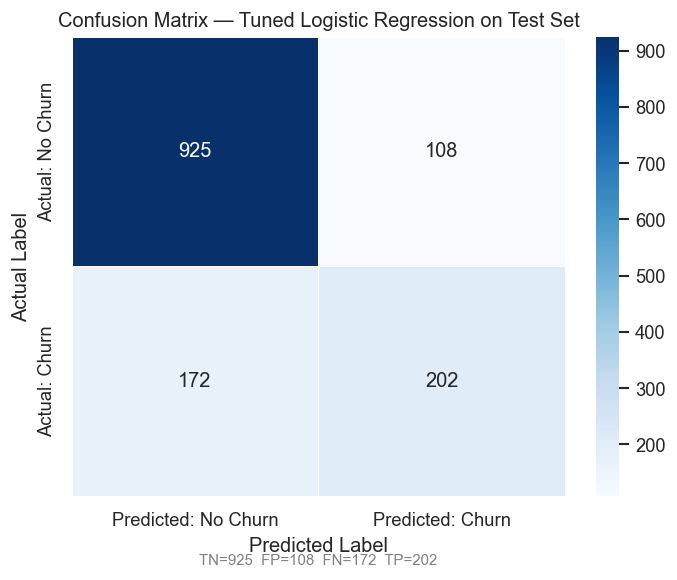

Churners correctly caught (TP):   202  (54.0% of actual churners)
Churners missed (FN):             172  (46.0% of actual churners)
False alarms (FP):                108


In [35]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'],
            linewidths=0.5, ax=ax)

ax.set_title('Confusion Matrix — Tuned Logistic Regression on Test Set')
ax.set_ylabel('Actual Label')
ax.set_xlabel('Predicted Label')

# Annotate with plain English labels
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.15,
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix.png'), bbox_inches='tight')
plt.show()

print(f'Churners correctly caught (TP):   {tp}  ({tp/(tp+fn)*100:.1f}% of actual churners)')
print(f'Churners missed (FN):             {fn}  ({fn/(tp+fn)*100:.1f}% of actual churners)')
print(f'False alarms (FP):                {fp}')

### Step 7 Findings

**Final test set ROC-AUC: 0.8414.** This is 0.009 below the cross-validation score of 0.8508 — a small and expected drop that confirms the model generalised well to unseen data without significant overfitting.

**Accuracy of 80.1% is misleading in isolation.** A naive model predicting nobody churns would achieve 73.4% accuracy. The 6.7 percentage point improvement is real but modest — the more informative metrics are precision and recall.

**Precision: 0.65 — of every 10 customers flagged as churners, 6-7 actually churned.** The false alarm rate is acceptable — 108 loyal customers would receive unnecessary retention offers, a manageable operational cost.

**Recall: 0.54 — the model's critical weakness.** Only 202 of 374 actual churners were caught. 172 churners (46%) were missed entirely and will leave without any intervention. In a telecom context where acquiring a new customer costs significantly more than retaining one, each missed churner represents a direct revenue loss.

**The precision-recall tradeoff points to a clear improvement path.** The default decision threshold of 0.5 is not optimised for this business problem. Lowering the threshold would increase recall at the cost of precision — flagging more customers for intervention and accepting more false alarms in exchange for catching more real churners.

# SAVE FIRST

# git add customer_churn_prediction.ipynb
# git commit -m "Step 7 — final evaluation, ROC-AUC 0.8414, recall 0.54 on test set"
# git push origin main